<a href="https://colab.research.google.com/github/renemorenow/MachineLearning2/blob/main/Prog_Basica_Python/Guia3_EntregaFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### [Abrir en Github](https://github.com/renemorenow/MachineLearning2/blob/main/Prog_Basica_Python/Guia3_Entrega.ipynb) ☝


#Integrantes

Andersson Camilo Ordoñez Ruiz. Cédula de ciudadanía: 1061750759

Miguel Felipe Corredor Montejo. Cédula de ciudadanía: 1098794311

William Rene Moreno Romero. Cédula de ciudadanía: 74329638

# **Guía 3**

## **¿Cómo podemos controlar el creciente número de accidentes en Nueva York?**

## Introduccion

**Contexto empresarial.** La ciudad de Nueva York ha experimentado un aumento en el número de accidentes en las carreteras de la ciudad. Quieren saber si el número de accidentes ha aumentado en las últimas semanas. Para todos los accidentes reportados, han recopilado detalles para cada accidente y han estado manteniendo registros durante el último año y medio (desde enero de 2018 hasta agosto de 2019).

La ciudad te ha contratado para que construyas visualizaciones que les ayuden a identificar patrones en accidentes, lo que les ayudaría a tomar acciones preventivas para reducir la cantidad de accidentes en el futuro. Tienen ciertos parámetros como municipio, hora del día, motivo del accidente, etc. De los que se preocupan y de los que les gustaría obtener información específica.

**Problema comercial.** Su tarea es formatear los datos proporcionados y proporcionar visualizaciones que respondan las preguntas específicas que tiene el cliente, que se mencionan a continuación.

**Contexto analítico.** Se le proporciona un archivo CSV (accidente) que contiene detalles sobre cada accidente, como fecha, hora, ubicación del accidente, motivo del accidente, tipos de vehículos involucrados, recuento de lesiones y muertes, etc. El delimitador en el archivo CSV dado es `;` en lugar del predeterminado **`,`**.

Realizará las siguientes tareas con los datos:

1. Leer, transformar y preparar datos para su visualización
2. Realizar análisis y construir visualizaciones de los datos para identificar patrones en el conjunto de datos.
        
El cliente tiene un conjunto específico de preguntas a las que le gustaría obtener respuestas. Deberá proporcionar visualizaciones para acompañar estos:

1. ¿Cómo ha fluctuado el número de accidentes durante el último año y medio? ¿Han aumentado con el tiempo?
2. Para un día en particular, ¿durante qué horas es más probable que ocurran accidentes?
3. ¿Hay más accidentes entre semana que durante los fines de semana?
4. ¿Cuál es la proporción de recuento de accidentes por área por municipio? ¿Qué distritos tienen un número desproporcionadamente grande de accidentes para su tamaño?
5. Para cada municipio, ¿durante qué horas es más probable que ocurran accidentes?
6. ¿Cuáles son las 5 principales causas de accidentes en la ciudad?
7. ¿Qué tipos de vehículos están más involucrados en accidentes por municipio?
8. ¿Qué tipos de vehículos están más involucrados en las muertes?

## Overview de la data

Analizemos las columnas presentes en el data frame

Este conjunto de datos contiene información detallada sobre accidentes de tránsito registrados en la ciudad de Nueva York. A continuación, se presenta la descripción de cada columna:

- **BOROUGH**. Municipio donde ocurrió el accidente (ejemplo: Manhattan, Brooklyn, Queens, Bronx, Staten Island).
- **COLLISION_ID** Identificador único asignado a cada colisión para diferenciar los accidentes registrados.
- **CONTRIBUTING FACTOR VEHICLE** (1, 2, 3, 4, 5) Factores que contribuyeron a la ocurrencia del accidente, como exceso de velocidad, distracción del conductor, fallas mecánicas, malas condiciones climáticas, entre otros.
Se pueden registrar hasta cinco factores por accidente, cada uno correspondiente a un vehículo involucrado.
- **CROSS STREET NAME**  Nombre de la calle transversal más cercana al lugar del accidente, útil para ubicar intersecciones peligrosas.
- **DATE** Fecha exacta en la que ocurrió el accidente en formato YYYY-MM-DD.
- **TIME** Hora del accidente en formato HH:MM AM/PM, permitiendo analizar patrones horarios en la siniestralidad.
- **LATITUDE y LONGITUDE**

- **NUMBER OF (CYCLISTS, MOTORISTS, PEDESTRIANS) INJURED** Número de personas heridas en el accidente, clasificadas en tres categorías: Ciclistas, Motociclistas - conductores de vehículos y Peatones.

- **NUMBER OF (CYCLISTS, MOTORISTS, PEDESTRIANS) DEATHS** Número de víctimas fatales en el accidente, categorizadas en: ciclistas, Motociclistas - conductores de vehículos y Peatones.

- **ON STREET NAME**  Nombre de la calle donde ocurrió el accidente, información clave para el análisis de zonas de alto riesgo.

- **VEHICLE TYPE CODE (1, 2, 3, 4, 5)** Tipos de vehículos involucrados en el accidente, pudiendo haber hasta cinco vehículos registrados por accidente.
Sedán, SUV, Camión, Motocicleta, Autobús, Bicicleta, etc.

- **ZIP CODE**  Código postal correspondiente a la ubicación del accidente, útil para agrupar eventos por áreas específicas dentro de la ciudad.

In [2]:
# Solución propuesta
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

In [3]:
# Importar los datos en 2 archivos debido a que github solo permite max 25MB por archivo:
url1 = 'https://raw.githubusercontent.com/renemorenow/MachineLearning2/refs/heads/main/Prog_Basica_Python/accidents-1.csv'
url2 = 'https://raw.githubusercontent.com/renemorenow/MachineLearning2/refs/heads/main/Prog_Basica_Python/accidents-2.csv'
df1 = pd.read_csv(url1, index_col=False, sep=';', parse_dates=['DATE'], dayfirst=False)
df2 = pd.read_csv(url2, index_col=False, sep=';', parse_dates=['DATE'], dayfirst=False)

In [4]:
df = pd.concat([df1, df2])

In [5]:
df.head()

,DATE,TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,ON STREET NAME,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,2018-09-26,12:12,BRONX,10454.0,40.808987,-73.911316,NaN,0,0,0,...,NaN,NaN,NaN,NaN,3988123,Sedan,NaN,NaN,NaN,NaN
1,2018-09-25,16:30,BROOKLYN,11236.0,40.636005,-73.912510,FLATLANDS AVENUE,1,0,0,...,NaN,NaN,NaN,NaN,3987962,Sedan,NaN,NaN,NaN,NaN
2,2019-08-22,19:30,QUEENS,11101.0,40.755490,-73.939530,NaN,0,0,0,...,NaN,NaN,NaN,NaN,4193132,Sedan,NaN,NaN,NaN,NaN
3,2018-09-23,13:10,QUEENS,11367.0,NaN,NaN,MAIN STREET,0,0,1,...,Unspecified,NaN,NaN,NaN,3985962,Bike,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN
4,2019-08-20,22:40,BRONX,10468.0,40.868336,-73.901270,NaN,0,0,0,...,Unspecified,NaN,NaN,NaN,4192111,Sedan,Sedan,NaN,NaN,NaN


In [6]:
#Cantidad de filas y columnas del DF
df.shape

(238522, 24)

In [7]:
#tipos de datos del DF:
df.dtypes

,0
DATE,datetime64[ns]
TIME,object
BOROUGH,object
ZIP CODE,float64
LATITUDE,float64
LONGITUDE,float64
ON STREET NAME,object
NUMBER OF PEDESTRIANS INJURED,int64
NUMBER OF PEDESTRIANS KILLED,int64
NUMBER OF CYCLIST INJURED,int64


### **Limpieza del dataset**

Para asegurar que los datos sean consistentes y puedan ser analizados correctamente, realizaremos la imputación de los valores faltantes en las columnas que presentan datos nulos. A continuación, se detallan los pasos que debes seguir para limpiar el conjunto de datos.
- **Paso 1: Identificar los valores faltantes**
- **Paso 2: Decidir el método de imputación**

Dado el análisis de valores nulos, se aplicarán diferentes estrategias de imputación según el tipo de dato. Por ejemplo: para la columna ZIP CODE, se imputará con el código postal más frecuente (moda) dentro de cada municipio registrado en BOROUGH. En el caso de las coordenadas LATITUDE y LONGITUDE, se reemplazarán los valores faltantes con la media de las coordenadas dentro de cada municipio. La columna ON STREET NAME será rellenada con "UNKNOWN" en caso de estar vacía. Para los factores que contribuyeron al accidente (CONTRIBUTING FACTOR VEHICLE X), los valores nulos serán sustituidos por "Unspecified". Finalmente, en las columnas de VEHICLE TYPE CODE X, los valores ausentes se reemplazarán con "Unknown" para asegurar la integridad del análisis.

#### Paso 1: Identificar los valores faltantes

In [8]:
# ==============================
#  Identificar valores faltantes
# ==============================
print(" Valores faltantes en cada columna:")
print(df.isnull().sum())

 Valores faltantes en cada columna:
DATE                                  0
TIME                                  0
BOROUGH                               0
ZIP CODE                             70
LATITUDE                           6978
LONGITUDE                          6978
ON STREET NAME                    84604
NUMBER OF PEDESTRIANS INJURED         0
NUMBER OF PEDESTRIANS KILLED          0
NUMBER OF CYCLIST INJURED             0
NUMBER OF CYCLIST KILLED              0
NUMBER OF MOTORIST INJURED            0
NUMBER OF MOTORIST KILLED             0
CONTRIBUTING FACTOR VEHICLE 1       884
CONTRIBUTING FACTOR VEHICLE 2     40008
CONTRIBUTING FACTOR VEHICLE 3    225450
CONTRIBUTING FACTOR VEHICLE 4    235666
CONTRIBUTING FACTOR VEHICLE 5    237730
COLLISION_ID                          0
VEHICLE TYPE CODE 1                1721
VEHICLE TYPE CODE 2               55590
VEHICLE TYPE CODE 3              226221
VEHICLE TYPE CODE 4              235806
VEHICLE TYPE CODE 5              237769
dtyp

In [9]:
#=====================================
#Filtrar filas con valores faltantes
#=====================================

df_isnull = df[df.isnull().any(axis=1)]
print(df_isnull.shape)
df_isnull.head()

(238070, 24)


,DATE,TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,ON STREET NAME,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,2018-09-26,12:12,BRONX,10454.0,40.808987,-73.911316,NaN,0,0,0,...,NaN,NaN,NaN,NaN,3988123,Sedan,NaN,NaN,NaN,NaN
1,2018-09-25,16:30,BROOKLYN,11236.0,40.636005,-73.912510,FLATLANDS AVENUE,1,0,0,...,NaN,NaN,NaN,NaN,3987962,Sedan,NaN,NaN,NaN,NaN
2,2019-08-22,19:30,QUEENS,11101.0,40.755490,-73.939530,NaN,0,0,0,...,NaN,NaN,NaN,NaN,4193132,Sedan,NaN,NaN,NaN,NaN
3,2018-09-23,13:10,QUEENS,11367.0,NaN,NaN,MAIN STREET,0,0,1,...,Unspecified,NaN,NaN,NaN,3985962,Bike,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN
4,2019-08-20,22:40,BRONX,10468.0,40.868336,-73.901270,NaN,0,0,0,...,Unspecified,NaN,NaN,NaN,4192111,Sedan,Sedan,NaN,NaN,NaN


#### Paso 2: Decidir el método de imputación

In [10]:
# ==============================
# ESTRATEGIAS DE IMPUTACIÓN PARA 'ZIP CODE'
# ==============================

# Imputación con la moda (valor más frecuente)
df_moda = df.copy()
print('Nulos iniciales:', f"{df_moda['ZIP CODE'].isnull().sum()}")
df_moda['ZIP CODE'].fillna(df_moda['ZIP CODE'].mode()[0], inplace=True)
df_moda['ZIP CODE'].value_counts(dropna=False)
print('Nulos finales:', f"{df_moda['ZIP CODE'].isnull().sum()}")

Nulos iniciales: 70
Nulos finales: 0


<ipython-input-10-e3c0a19447e6>:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_moda['ZIP CODE'].fillna(df_moda['ZIP CODE'].mode()[0], inplace=True)


In [11]:
df_moda['ZIP CODE'].isnull().sum()

0

In [12]:
# Imputación con la media (promedio)
df_media = df.copy()
print('Nulos iniciales:', f"LATITUDE: {df_media['LONGITUDE'].isnull().sum()}, LATITUDE: {df_media['LATITUDE'].isnull().sum()}")
df_media['LATITUDE'].fillna(df_media['LATITUDE'].mean(), inplace=True)
df_media['LONGITUDE'].fillna(df_media['LONGITUDE'].mean(), inplace=True)
print('Nulos finales:', f"LATITUDE: {df_media['LONGITUDE'].isnull().sum()}, LATITUDE: {df_media['LATITUDE'].isnull().sum()}")

Nulos iniciales: LATITUDE: 6978, LATITUDE: 6978
Nulos finales: LATITUDE: 0, LATITUDE: 0


<ipython-input-12-af858c929c3b>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_media['LATITUDE'].fillna(df_media['LATITUDE'].mean(), inplace=True)
<ipython-input-12-af858c929c3b>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

In [13]:
# Imputación con 'UNKNOWN'
print('Nulos iniciales:', df['ON STREET NAME'].isnull().sum())
df_desconocido = df.copy()
df_desconocido['ON STREET NAME'].fillna('UNKNOWN', inplace=True)
print('Nulos finales:', df_desconocido['ON STREET NAME'].isnull().sum())

Nulos iniciales: 84604
Nulos finales: 0


<ipython-input-13-bfc115c564a5>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_desconocido['ON STREET NAME'].fillna('UNKNOWN', inplace=True)


In [14]:
# Imputación para 'CONTRIBUTING FACTOR VEHICLE X' con 'Unspecified'
df_Unspecified = df.copy()
for i in range(1, 6):
  print('Nulos iniciales:', df_Unspecified[f'CONTRIBUTING FACTOR VEHICLE {i}'].isnull().sum())
  df_Unspecified[f'CONTRIBUTING FACTOR VEHICLE {i}'].fillna('Unspecified', inplace=True)
  print('Nulos finales:', df_Unspecified[f'CONTRIBUTING FACTOR VEHICLE {i}'].isnull().sum())

<ipython-input-14-466dc46c6224>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_Unspecified[f'CONTRIBUTING FACTOR VEHICLE {i}'].fillna('Unspecified', inplace=True)


Nulos iniciales: 884
Nulos finales: 0
Nulos iniciales: 40008
Nulos finales: 0
Nulos iniciales: 225450
Nulos finales: 0
Nulos iniciales: 235666
Nulos finales: 0
Nulos iniciales: 237730
Nulos finales: 0


In [15]:
# Imputación para 'VEHICLE TYPE CODE X' con 'Unknown'
df_Unknown = df.copy()
for i in range(1, 6):
  print('Nulos iniciales:', df_Unknown[f'VEHICLE TYPE CODE {i}'].isnull().sum())
  df_Unknown[f'VEHICLE TYPE CODE {i}'].fillna('Unknown', inplace=True)
  print('Nulos finales:', df_Unknown[f'VEHICLE TYPE CODE {i}'].isnull().sum())

Nulos iniciales: 1721
Nulos finales: 0
Nulos iniciales: 55590
Nulos finales: 0
Nulos iniciales: 226221
Nulos finales: 0
Nulos iniciales: 235806
Nulos finales: 0
Nulos iniciales: 237769
Nulos finales: 0


<ipython-input-15-3d2266b0a54e>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_Unknown[f'VEHICLE TYPE CODE {i}'].fillna('Unknown', inplace=True)


### Ejercicio 1

Desde 2014, la ciudad de Nueva York ha estado implementando el programa de seguridad vial Vision Zero, cuyo objetivo es reducir a cero el número de muertes por accidentes de tránsito para el año 2024. Como parte de esta iniciativa, se han implementado y mejorado diversas estrategias para aumentar la seguridad en las calles.

A continuación, se presentan algunas de las medidas adoptadas en el plan:

- [ ] Detección automatizada de peatones para mejorar la seguridad en los cruces.
- [ ] Auditorías de seguridad vial en zonas con alta incidencia de accidentes.
- [ ] Expansión de la red de carriles para bicicletas para reducir la exposición de ciclistas a incidentes con vehículos.
- [ ] Programas de educación y sensibilización para fomentar el respeto a las normas de tránsito.
- [ ] Construcción de islas de refugio peatonal para mejorar la seguridad en calles de alto tráfico.
- [ ] Implementación de reductores de velocidad inteligentes, como topes y amortiguadores, basados en el análisis de datos.

**Pregunta: ¿Cuáles de estas iniciativas podrían beneficiarse directamente del análisis de los datos disponibles sobre accidentes? Marque todas las opciones que considere aplicables.**

Instrucciones: Para marcar una opción, agregue una "[x]" en la casilla correspondiente.

#### Justificación:
- [X] Detección automatizada de peatones para mejorar la seguridad en los cruces.
  
Con la información de los peatones y las coordenadas, se puede analizar y encontrar los cruces con mayor indice de accidentes peatonales, para implementar dispositivos que ayuden a este tipo de detección.

- [X] Auditorías de seguridad vial en zonas con alta incidencia de accidentes.

Se puede identificar las areas con mayor siniestralidad, a partir de los datos como cantidad de personas heridas o fallecidas y ubicación geografica; con el fin de generar planes especificos para reducir los accidentes en estas areas.

- [X] Expansión de la red de carriles para bicicletas para reducir la exposición de ciclistas a incidentes con vehículos.

Usando datos como el numero de ciclistas heridos o muertos y su respectiva ubicación, se puede identificar que calles son mas peligrosas para los ciclistas y se podría construir ciclorutas en estas ubicaciones.

- [X] Programas de educación y sensibilización para fomentar el respeto a las normas de tránsito.

Se puede identificar los patrones comunes en comportamientos peligrosos a partir del campo 'CONTRIBUTING FACTOR VEHICLE' (exceso de velocidad, distracción del conductor o no ceder el paso, etc). Esto permitiría generar campañas educativas enfocadas en los problemas más frecuentes.

- [X] Construcción de islas de refugio peatonal para mejorar la seguridad en calles de alto tráfico.

El analisis de accidentes con peatones involucrados y la información de las calles donde ocurrieron, se puede identificar zonas para posible construcción de islas de refugio para disminuir la accidentalidad.

- [X] Implementación de reductores de velocidad inteligentes, como topes y amortiguadores, basados en el análisis de datos.

Se puede analizar factores como el exceso de velocidad, ubicación geografica y fallas en la conducción, para la generación de los accidentes, con lo cual se puede identificar sitios espeficicos para instalación de reductores de velocidad.

### **Sigamos adelante y respondamos a cada una de las preguntas del cliente.**

### Ejercicio 2:

Agrupe los datos disponibles mensualmente y genere un line plot de accidentes a lo largo del tiempo. ¿Ha aumentado el número de accidentes durante el último año y medio?

**Sugerencia**: Puede encontrar útiles las funciones de pandas ```to_datetime ()``` y ```dt.to_period ()```.


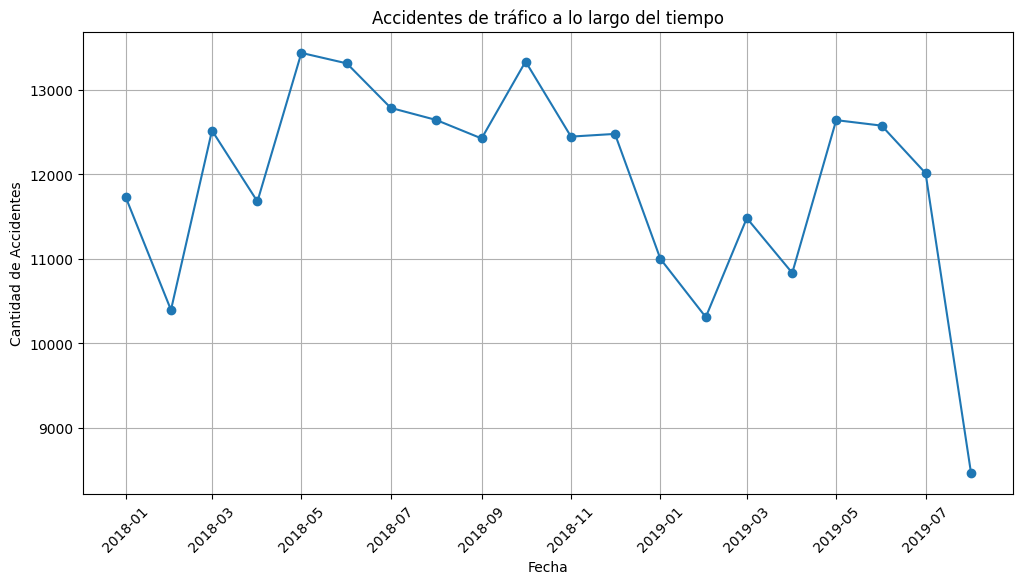

In [201]:
# Extraer año y mes
df['YearMonth'] = df['DATE'].dt.to_period('M')

# Contar accidentes por mes
accidents_per_month = df.groupby('YearMonth').size()

# Convertir el índice a fecha para graficar correctamente
accidents_per_month.index = accidents_per_month.index.to_timestamp()

# Graficar
plt.figure(figsize=(12, 6))
plt.plot(accidents_per_month.index, accidents_per_month.values, marker='o', linestyle='-')
plt.xlabel("Fecha")
plt.ylabel("Cantidad de Accidentes")
plt.title("Accidentes de tráfico a lo largo del tiempo")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


El gráfico de líneas que trazamos muestra claramente que no hay una tendencia alcista obvia en los accidentes a lo largo del tiempo.

De la gráfica anterior, ¿qué meses parecen tener el menor número de accidentes? ¿Cuáles crees que son las razones detrás de esto?

Respuesta: Los meses con menos accidentes parecen ser enero de 2019 y agosto de 2019. *Posibles razones detrás de esto:*
Enero: En invierno, hay menos tráfico debido a condiciones climáticas adversas (nieve, hielo), lo que puede reducir el número de vehículos en la carretera.
Agosto: Es un mes de vacaciones, lo que podría significar menos tráfico en la ciudad.

### Exjercicio 3:
¿Cómo varía el número de accidentes a lo largo de un solo día? Cree una nueva columna `HOUR` basada en los datos de la columna `TIME`, luego trace un gráfico de barras de la distribución por hora a lo largo del día.

**Sugerencia:** Puede encontrar útil la función ```dt.hour```.

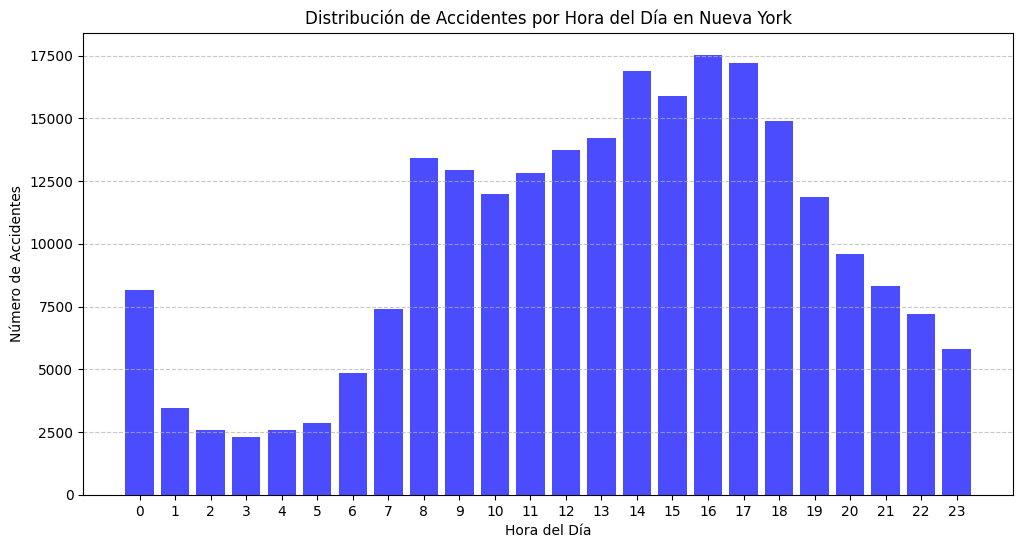

In [202]:
# Convertir la columna 'TIME' a formato datetime para extraer la hora
df['TIME'] = pd.to_datetime(df['TIME'], format='%H:%M', errors='coerce')

# Crear la columna 'HOUR' con la hora del accidente
df['HOUR'] = df['TIME'].dt.hour

# Contar la cantidad de accidentes por hora
accidents_per_hour = df['HOUR'].value_counts().sort_index()

# Graficar la distribución de accidentes por hora del día
plt.figure(figsize=(12, 6))
plt.bar(accidents_per_hour.index, accidents_per_hour, color='b', alpha=0.7)
plt.xlabel('Hora del Día')
plt.ylabel('Número de Accidentes')
plt.title('Distribución de Accidentes por Hora del Día en Nueva York')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

En la pregunta anterior hemos agregado el número de accidentes por hora sin tener en cuenta la fecha y el lugar en que ocurrieron. ¿Qué crítica le daría a este enfoque?

Respuesta: No distingue entre días laborales y fines de semana: El tráfico varía entre estos periodos.
No considera la ubicación de los accidentes: Puede haber diferencias entre zonas urbanas y suburbanas.

### Ejercicio 4:

¿Cómo varía el número de accidentes en una sola semana? Trace un gráfico de barras basado en el recuento de accidentes por día de la semana.

**Sugerencia:** Puede encontrar útil la función ```dt.weekday```.

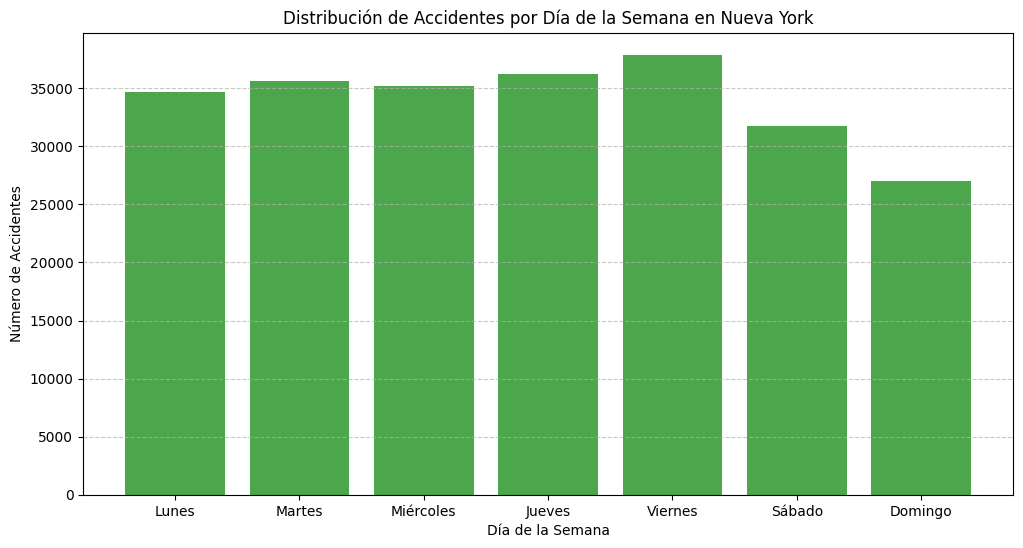

In [203]:
# Crear una nueva columna con el día de la semana (0 = Lunes, 6 = Domingo)
df['WEEKDAY'] = df['DATE'].dt.weekday

# Diccionario para mapear números a nombres de días
dias_semana = {
    0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves',
    4: 'Viernes', 5: 'Sábado', 6: 'Domingo'
}

# Contar el número de accidentes por día de la semana
accidents_per_weekday = df['WEEKDAY'].value_counts().sort_index()
accidents_per_weekday.index = accidents_per_weekday.index.map(dias_semana)

# Graficar la distribución de accidentes por día de la semana
plt.figure(figsize=(12, 6))
plt.bar(accidents_per_weekday.index, accidents_per_weekday, color='g', alpha=0.7)
plt.xlabel('Día de la Semana')
plt.ylabel('Número de Accidentes')
plt.title('Distribución de Accidentes por Día de la Semana en Nueva York')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Ejercicio 5:

Trace una gráfica de barras del número total de accidentes en cada municipio, así como uno de los accidentes por milla cuadrada por municipio. ¿Qué puedes concluir?

**Sugerencia:** Es posible que desee actualizar algunas de las claves en el diccionario del municipio para que coincidan con los nombres en el marco de datos.

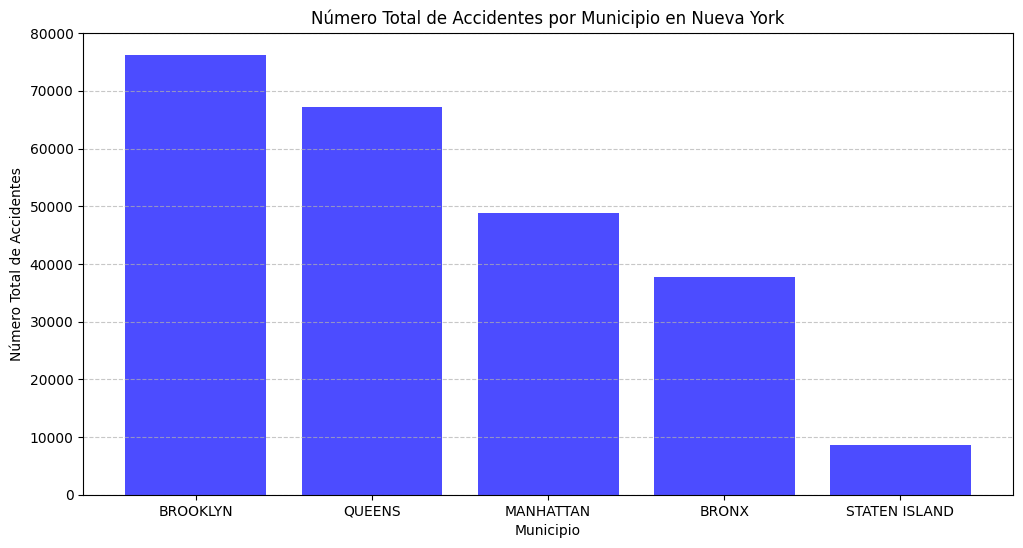

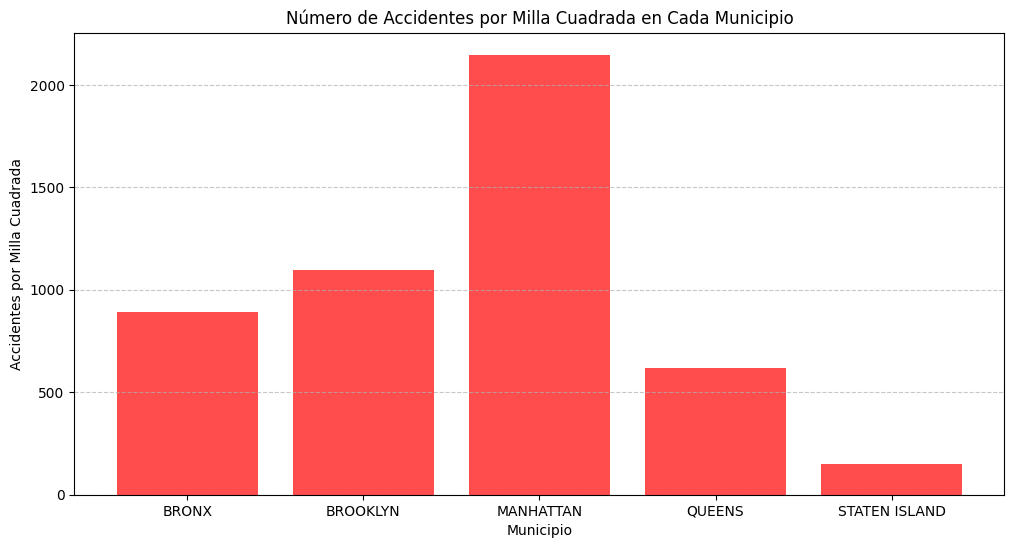

In [204]:
# Definir el área en millas cuadradas según Wikipedia
borough_areas_corrected = {
    'BRONX': 42.2,
    'BROOKLYN': 69.4,
    'MANHATTAN': 22.7,
    'QUEENS': 108.7,
    'STATEN ISLAND': 57.5
}

# Asegurar que los nombres en el dataset coincidan con los del diccionario
df['BOROUGH'] = df['BOROUGH'].str.upper()

# Contar el número total de accidentes por municipio
accidents_per_borough = df['BOROUGH'].value_counts()

# Calcular accidentes por milla cuadrada usando los valores corregidos
accidents_per_sq_mile = accidents_per_borough / pd.Series(borough_areas_corrected)

# Graficar el número total de accidentes por municipio
plt.figure(figsize=(12, 6))
plt.bar(accidents_per_borough.index, accidents_per_borough, color='b', alpha=0.7)
plt.xlabel('Municipio')
plt.ylabel('Número Total de Accidentes')
plt.title('Número Total de Accidentes por Municipio en Nueva York')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Graficar los accidentes por milla cuadrada
plt.figure(figsize=(12, 6))
plt.bar(accidents_per_sq_mile.index, accidents_per_sq_mile, color='r', alpha=0.7)
plt.xlabel('Municipio')
plt.ylabel('Accidentes por Milla Cuadrada')
plt.title('Número de Accidentes por Milla Cuadrada en Cada Municipio')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Podemos ver que Brooklyn y Queens tienen un número muy alto de accidentes en relación con los otros tres condados. Pero, ¿qué tal por milla cuadrada?

Respuesta:
-Número total de accidentes por municipio:

** Brooklyn y Queens tienen el mayor número de accidentes.
** Manhattan, aunque más pequeño, también tiene una cantidad significativa de accidentes.
** Staten Island tiene el menor número de accidentes totales.

-Densidad de accidentes por milla cuadrada:

**Manhattan es el más peligroso, con la mayor cantidad de accidentes por milla cuadrada debido a su alta densidad de tráfico.
**Brooklyn y el Bronx también tienen una alta densidad de accidentes.
**Queens y Staten Island tienen menor densidad debido a su gran tamaño.

### Ejercicio 6:

¿Qué horas tienen más accidentes en cada municipio? Trace un gráfico de barras para cada municipio que muestre el número de accidentes por cada hora del día.

**Sugerencia:** Puede usar ```sns.FacetGrid``` para crear una cuadrícula de parcelas con los datos por hora de cada municipio.

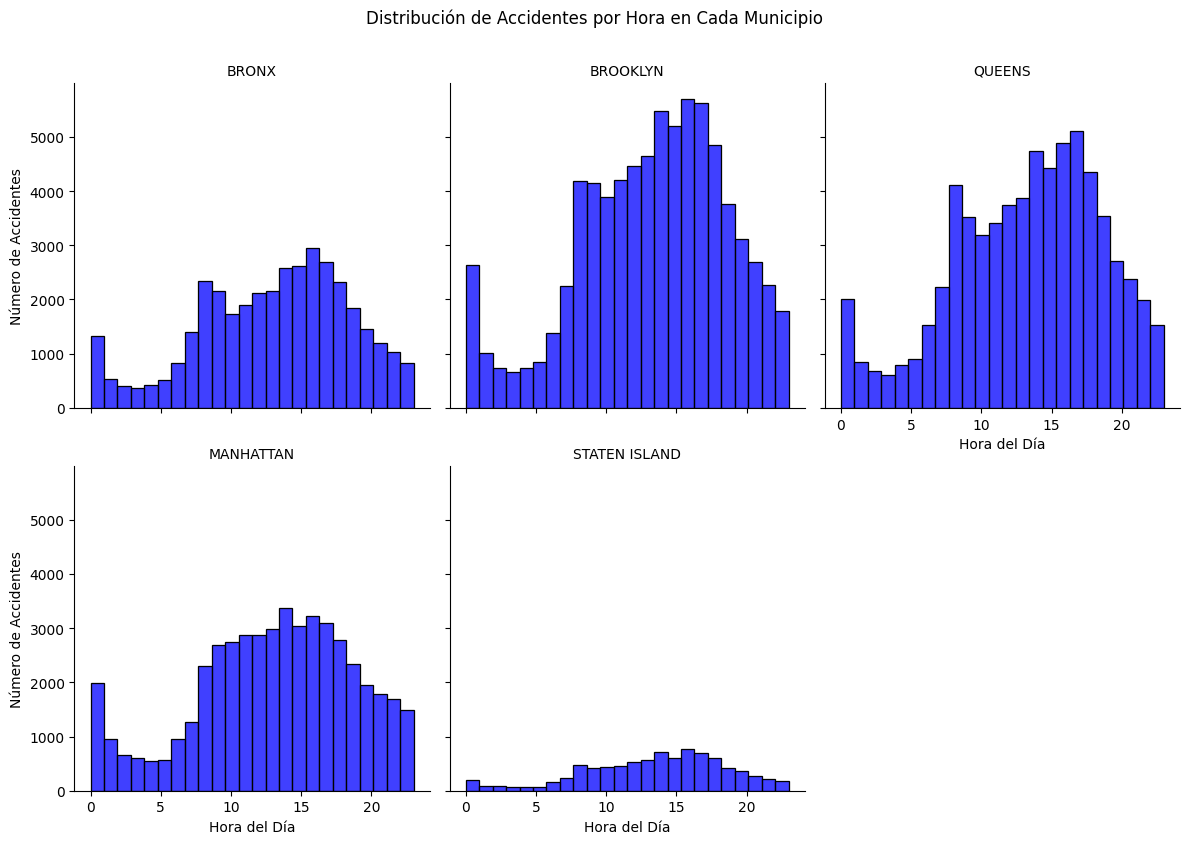

In [205]:
# Crear una nueva columna 'HOUR' si no está creada
if 'HOUR' not in df.columns:
    df['TIME'] = pd.to_datetime(df['TIME'], format='%H:%M', errors='coerce')
    df['HOUR'] = df['TIME'].dt.hour

# Filtrar datos válidos
df_filtered = df.dropna(subset=['BOROUGH', 'HOUR'])

# Configurar el gráfico con FacetGrid para visualizar los accidentes por hora en cada municipio
g = sns.FacetGrid(df_filtered, col="BOROUGH", col_wrap=3, height=4, sharex=True, sharey=True)
g.map_dataframe(sns.histplot, x="HOUR", bins=24, kde=False, color="b")

# Configurar etiquetas
g.set_axis_labels("Hora del Día", "Número de Accidentes")
g.set_titles(col_template="{col_name}")
g.fig.suptitle("Distribución de Accidentes por Hora en Cada Municipio", y=1.05)
plt.show()

**¿Es mayor el número de accidentes en diferentes momentos en diferentes distritos? ¿Deberíamos concentrarnos en diferentes momentos para cada municipio?**

Respuesta:

Sí, el número de accidentes varía por hora del día en cada municipio. Los patrones de tráfico y densidad poblacional afectan la distribución de accidentes. A partir de los gráficos:

- Brooklyn y Queens:

Tienen picos de accidentes en horas pico (7-9 AM y 4-7 PM).

- Manhattan:

Muestra un alto volumen de accidentes durante el día y la noche.
Su actividad comercial y de entretenimiento nocturno mantiene niveles constantes de accidentes.

- Bronx:

También presenta picos en las horas pico, pero con menor magnitud comparado con Brooklyn y Queens.

- Staten Island:

Registra el menor número de accidentes en todas las horas.
Su menor densidad de tráfico y menor actividad comercial pueden explicar esta tendencia.


### Ejercicio 7:

¿Qué factores provocan la mayoría de los accidentes? Evite contar dos veces los factores que contribuyen a un solo accidente.

**Sugerencia:** Una forma de lidiar con las repeticiones es concatenar las columnas correspondientes conservando sus índices, puede hacerlo con las funciones ```pd.concat()``` y ```reset_index()```. Luego, use un ```group_by``` apropiado para contar el número de repeticiones de factores contribuidos por accidente.

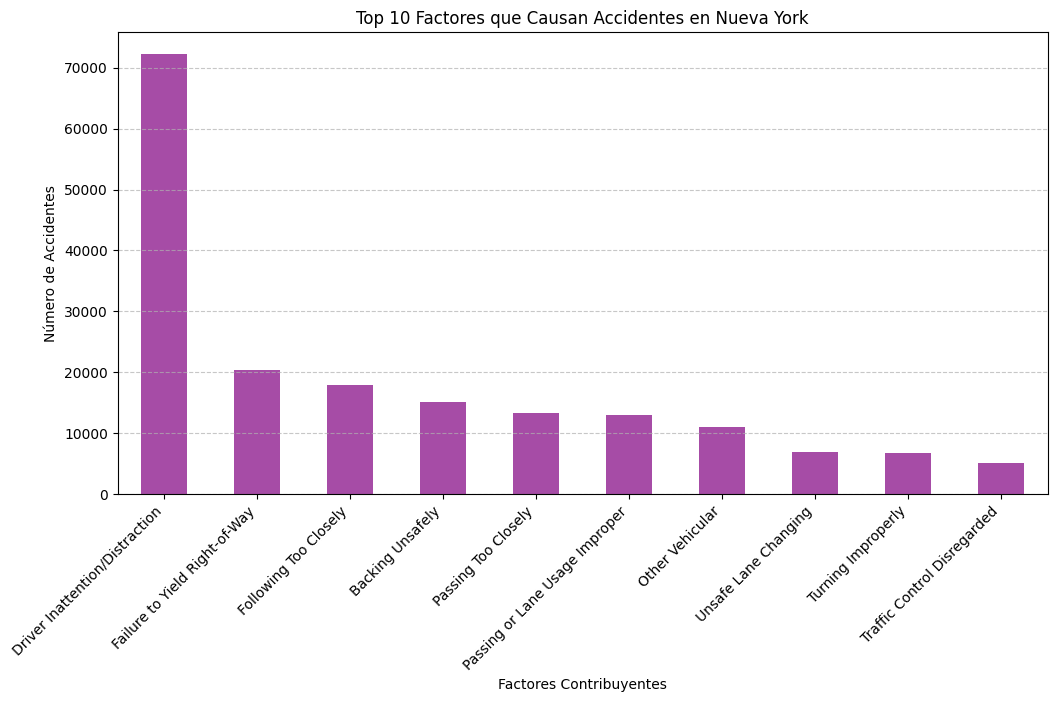

In [206]:
# Seleccionar las columnas de factores contribuyentes
factor_columns = [
    'CONTRIBUTING FACTOR VEHICLE 1', 'CONTRIBUTING FACTOR VEHICLE 2',
    'CONTRIBUTING FACTOR VEHICLE 3', 'CONTRIBUTING FACTOR VEHICLE 4',
    'CONTRIBUTING FACTOR VEHICLE 5'
]

# Concatenar todas las columnas en una sola serie para contar la frecuencia de cada factor
factors_series = pd.concat([df[col] for col in factor_columns], axis=0).reset_index(drop=True)

# Eliminar valores nulos y factores "Unspecified"
factors_series = factors_series.dropna()
factors_series = factors_series[factors_series.str.upper() != "UNSPECIFIED"]

# Contar la cantidad de veces que aparece cada factor
factor_counts = factors_series.value_counts()

# Graficar los 10 factores más comunes
plt.figure(figsize=(12, 6))
factor_counts.head(10).plot(kind='bar', color='purple', alpha=0.7)
plt.xlabel('Factores Contribuyentes')
plt.ylabel('Número de Accidentes')
plt.title('Top 10 Factores que Causan Accidentes en Nueva York')
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Ejercicio 8:

¿Qué tipos de vehículos están más involucrados en accidentes por municipio? Evite contar dos veces el tipo de vehículos presentes en un solo accidente.

**Sugerencia:** Puede aplicar un enfoque similar al utilizado en la pregunta anterior.

In [43]:
# Seleccionar columnas de municipio y tipos de vehículos
vehicle_columns = ['VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2', 'VEHICLE TYPE CODE 3', 'VEHICLE TYPE CODE 4', 'VEHICLE TYPE CODE 5']
# Concatenar todas las columnas en una sola serie para contar la frecuencia de cada tipo de vehículo
vehicles_series = pd.concat([df[col] for col in vehicle_columns], axis=0).reset_index(drop=True)

# Eliminar valores nulos y tipos "Unknown"
vehicles_series = vehicles_series.dropna()
vehicles_series = vehicles_series[vehicles_series.str.upper() != "UNKNOWN"]

df_melted = df.melt(id_vars=['BOROUGH', 'COLLISION_ID'], value_vars=vehicle_columns, value_name='VEHICLE_TYPE')

# Eliminar valores nulos y duplicados por accidente
df_melted = df_melted.dropna(subset=['VEHICLE_TYPE']).drop_duplicates(subset=['COLLISION_ID', 'VEHICLE_TYPE'])

# Contar ocurrencias de cada tipo de vehículo por municipio
vehicle_counts = df_melted.groupby(['BOROUGH', 'VEHICLE_TYPE']).size().reset_index(name='COUNT')
vehicle_counts = vehicle_counts.sort_values(by='COUNT', ascending=False)

# Imprimir los resultados
print(vehicle_counts)

            BOROUGH                         VEHICLE_TYPE  COUNT
510        BROOKLYN                                Sedan  39459
1161         QUEENS                                Sedan  35103
518        BROOKLYN  Station Wagon/Sport Utility Vehicle  32262
1165         QUEENS  Station Wagon/Sport Utility Vehicle  31647
866       MANHATTAN                                Sedan  20727
...             ...                                  ...    ...
696       MANHATTAN                                 COM.      1
699       MANHATTAN                                CONST      1
700       MANHATTAN                                 CONT      1
112           BRONX                                 MACK      1
1369  STATEN ISLAND                                van t      1

[1370 rows x 3 columns]


<Figure size 1200x600 with 0 Axes>

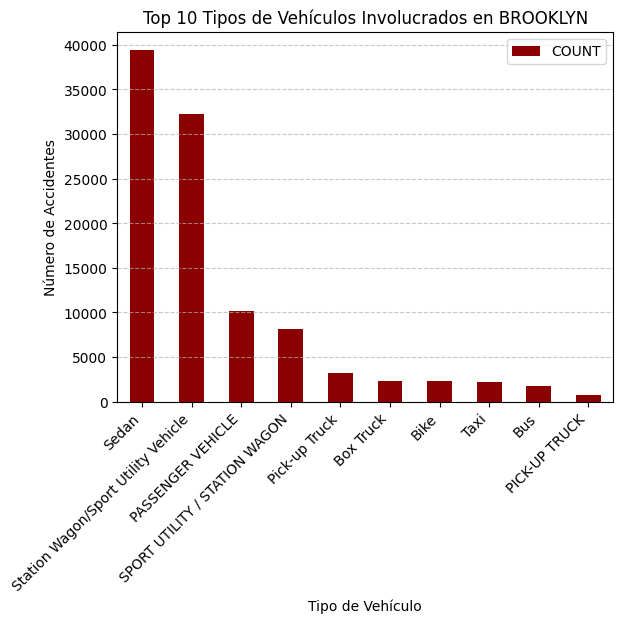

<Figure size 1200x600 with 0 Axes>

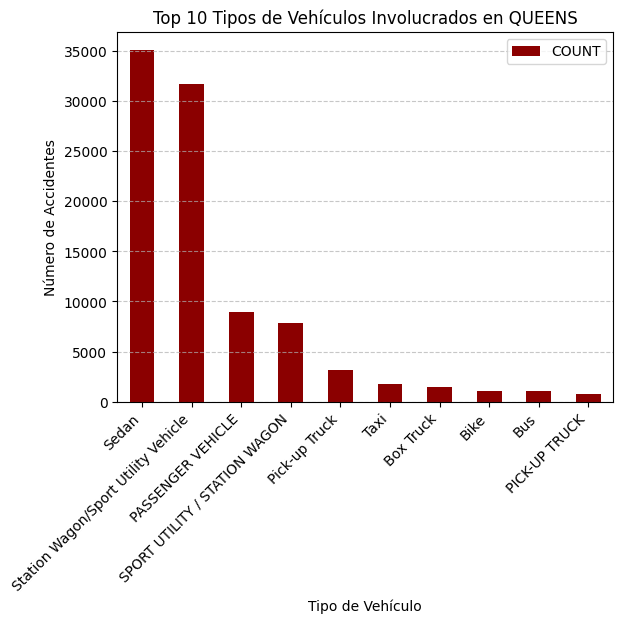

<Figure size 1200x600 with 0 Axes>

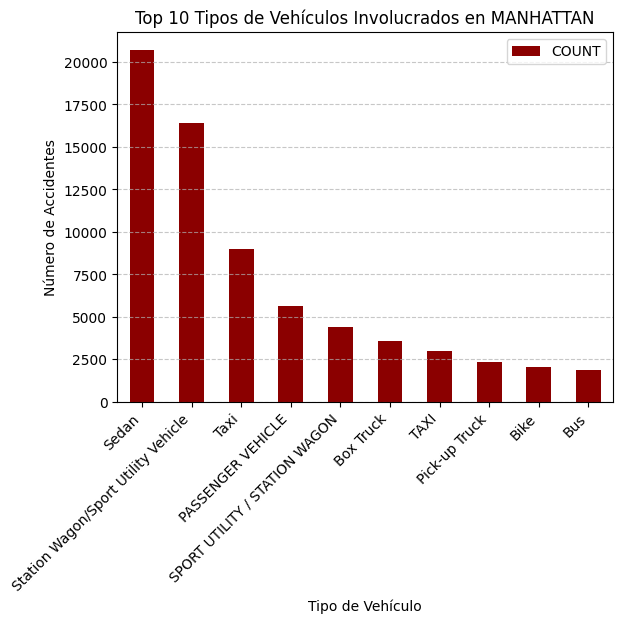

<Figure size 1200x600 with 0 Axes>

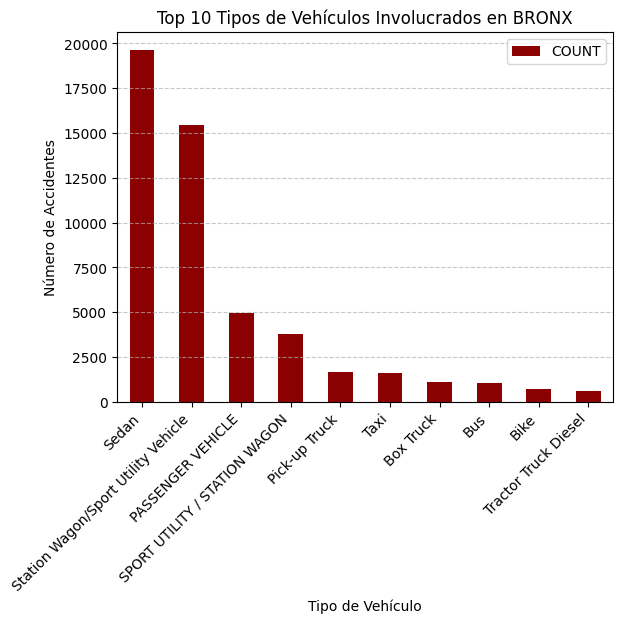

<Figure size 1200x600 with 0 Axes>

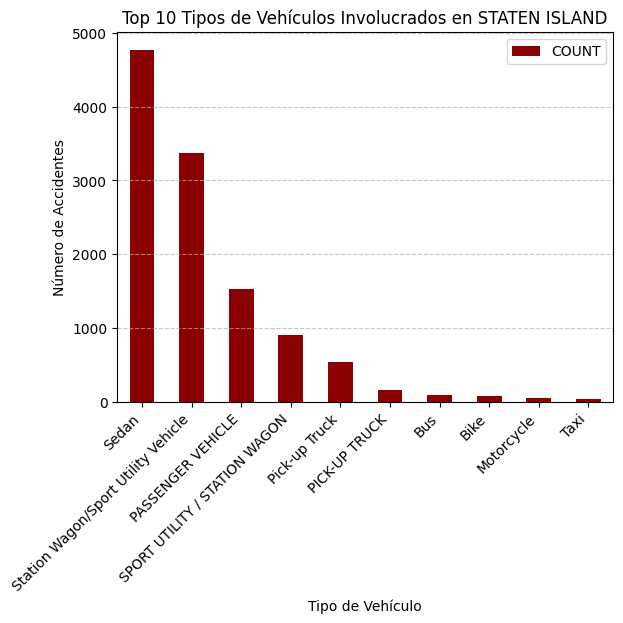

In [44]:
for BOROUGH in vehicle_counts["BOROUGH"].unique():
  vehicle_counts_tmp = vehicle_counts[vehicle_counts["BOROUGH"].str.contains(BOROUGH)]
  vehicle_counts_tmp = vehicle_counts_tmp.sort_values(by="COUNT", ascending=False)
  # Graficar los 10 tipos de vehículos más comunes en accidentes
  plt.figure(figsize=(12, 6))
  vehicle_counts_tmp.head(10).plot.bar('VEHICLE_TYPE', color='darkred')
  plt.xlabel('Tipo de Vehículo')
  plt.ylabel('Número de Accidentes')
  plt.title(f'Top 10 Tipos de Vehículos Involucrados en {BOROUGH}')
  plt.xticks(rotation=45, ha="right")
  plt.grid(axis='y', linestyle='--', alpha=0.7)
  plt.show()

In [100]:
vehicle_counts.groupby(['VEHICLE_TYPE']).agg(Total=("COUNT", "sum")).sort_values(by="Total", ascending=False).head(10)

,Total
VEHICLE_TYPE,
Sedan,119714
Station Wagon/Sport Utility Vehicle,99146
PASSENGER VEHICLE,31228
SPORT UTILITY / STATION WAGON,25059
Taxi,14584
Pick-up Truck,10864
Box Truck,8509
Bike,6264
Bus,5848


<Figure size 1200x600 with 0 Axes>

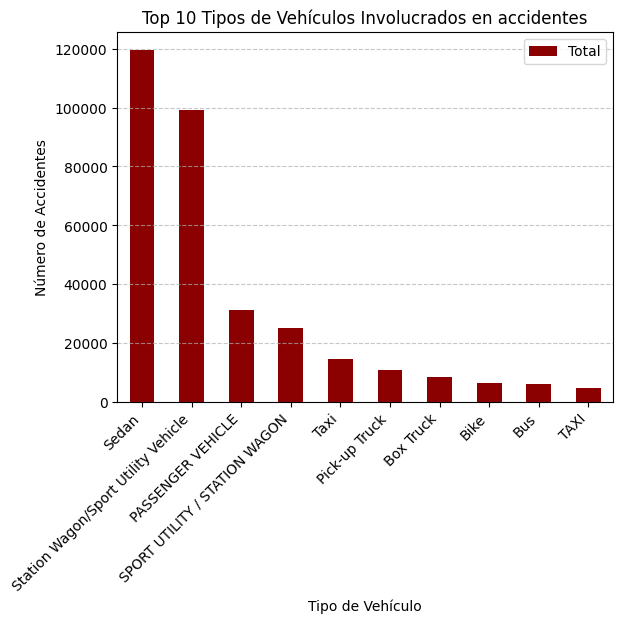

In [99]:
# Graficar los 10 tipos de vehículos más comunes en accidentes
plt.figure(figsize=(12, 6))
vehicle_counts_total = vehicle_counts.groupby(['VEHICLE_TYPE']).agg(Total=("COUNT", "sum")).sort_values(by="Total", ascending=False).head(10)
vehicle_counts_total.plot.bar(color='darkred')
plt.xlabel('Tipo de Vehículo')
plt.ylabel('Número de Accidentes')
plt.title(f'Top 10 Tipos de Vehículos Involucrados en accidentes')
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Tipos de vehículos más involucrados en accidentes:

-- Sedan y SUVs son los más comunes en los accidentes, lo cual es esperado porque son los tipos de vehículos más utilizados en la ciudad.
Vehículos de pasajeros y taxis también tienen una alta incidencia.
Camionetas pickup y camiones de carga (box trucks) están involucrados en una cantidad considerable de accidentes.



Distribución de vehículos involucrados por municipio:

-- Manhattan tiene una alta presencia de taxis en accidentes.

-- Brooklyn y Queens presentan una mayor cantidad de accidentes con SUVs y vehículos de pasajeros.

-- Staten Island tiene una cantidad mucho menor de accidentes, lo que es coherente con su menor densidad de tráfico.

### Ejercicio 9:

En 2018 para una [entrevista](https://www.nytimes.com/2019/01/01/nyregion/traffic-deaths-decrease-nyc.html) con The New York Times, el alcalde de Blasio de Nueva York declaró que *'Vision Zero está funcionando claramente'*. Ese año, el número de muertes en accidentes de tráfico en Nueva York se redujo a un histórico 202. Sin embargo, según lo informado por [am New York Metro](https://www.amny.com/news/vision-zero-de-blasio- 1-30707464 /), el número de víctimas mortales ha aumentado un 30% en el primer trimestre de 2019 en comparación con el año anterior y el número de peatones y ciclistas heridos no ha experimentado ninguna mejora.

¿Cómo utilizaría los datos proporcionados para comprender qué salió mal en el primer trimestre de 2019?


> - [ ] Considere los accidentes del primer trimestre de 2019. Luego, busque las causas más comunes de accidentes en los que estuvieron involucrados peatones y ciclistas. Dé una recomendación basada únicamente en esta información.

> - [x] Cree un par de mapas de calor de los accidentes que involucraron a peatones y ciclistas lesionados / muertos en el primer trimestre de 2018 y 2019. Compare estos dos para ver si hay algún cambio en la concentración de accidentes. En áreas críticas, estudie el tipo de factores involucrados en los accidentes. Dé una recomendación para visitar estas áreas para estudiar más el problema.   

> - [ ] Los datos proporcionados son insuficientes para mejorar nuestra comprensión de la situación.

> - [ ] Ninguna de las anteriores. Haría lo siguiente: *aquí tu respuesta recomendada*.

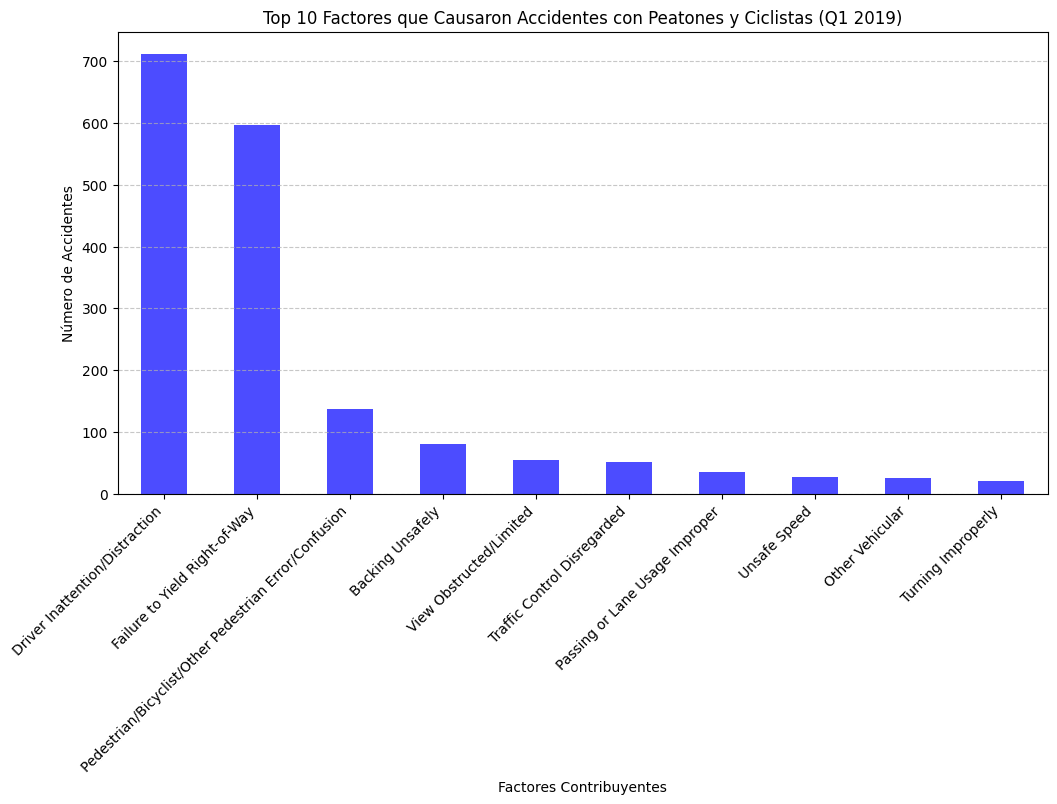

In [101]:

import folium
from folium.plugins import HeatMap

# Filtrar los datos del primer trimestre de 2018 y 2019
df['YEAR'] = df['DATE'].dt.year
df['MONTH'] = df['DATE'].dt.month

df_2018_q1 = df[(df['YEAR'] == 2018) & (df['MONTH'].isin([1, 2, 3]))]
df_2019_q1 = df[(df['YEAR'] == 2019) & (df['MONTH'].isin([1, 2, 3]))]

# Filtrar solo accidentes que involucraron peatones o ciclistas
df_2018_q1_ped_cyc = df_2018_q1[(df_2018_q1['NUMBER OF PEDESTRIANS INJURED'] > 0) |
                                 (df_2018_q1['NUMBER OF CYCLIST INJURED'] > 0)]
df_2019_q1_ped_cyc = df_2019_q1[(df_2019_q1['NUMBER OF PEDESTRIANS INJURED'] > 0) |
                                 (df_2019_q1['NUMBER OF CYCLIST INJURED'] > 0)]

# Crear mapa base de Nueva York
nyc_map = folium.Map(location=[40.7128, -74.0060], zoom_start=11)

# Agregar mapa de calor para 2018
heatmap_2018 = HeatMap(df_2018_q1_ped_cyc[['LATITUDE', 'LONGITUDE']].dropna(),
                       radius=10, blur=15, min_opacity=0.2, max_zoom=1)

nyc_map.add_child(heatmap_2018)
nyc_map.save("heatmap_2018.html")

# Crear mapa de calor para 2019
nyc_map_2019 = folium.Map(location=[40.7128, -74.0060], zoom_start=11)

heatmap_2019 = HeatMap(df_2019_q1_ped_cyc[['LATITUDE', 'LONGITUDE']].dropna(),
                       radius=10, blur=15, min_opacity=0.2, max_zoom=1)

nyc_map_2019.add_child(heatmap_2019)
nyc_map_2019.save("heatmap_2019.html")

# Contar las causas más comunes de accidentes con peatones y ciclistas en 2019
factor_columns = [
    'CONTRIBUTING FACTOR VEHICLE 1', 'CONTRIBUTING FACTOR VEHICLE 2',
    'CONTRIBUTING FACTOR VEHICLE 3', 'CONTRIBUTING FACTOR VEHICLE 4',
    'CONTRIBUTING FACTOR VEHICLE 5'
]

# Concatenar factores y limpiar datos
factors_2019 = pd.concat([df_2019_q1_ped_cyc[col] for col in factor_columns], axis=0).dropna()
factors_2019 = factors_2019[factors_2019.str.upper() != "UNSPECIFIED"]

# Contar las causas más comunes
factor_counts_2019 = factors_2019.value_counts()

# Graficar las 10 principales causas de accidentes con peatones y ciclistas en 2019
plt.figure(figsize=(12, 6))
factor_counts_2019.head(10).plot(kind='bar', color='blue', alpha=0.7)
plt.xlabel('Factores Contribuyentes')
plt.ylabel('Número de Accidentes')
plt.title('Top 10 Factores que Causaron Accidentes con Peatones y Ciclistas (Q1 2019)')
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Recomendaciones:

--Reforzar las campañas contra la distracción del conductor, ya que es la causa principal de accidentes.


--Implementar más controles en intersecciones críticas para mejorar la seguridad de peatones y ciclistas.

--Si la concentración de accidentes ha aumentado en zonas específicas, se deben implementar medidas de prevención más agresivas en esas áreas.

### Ejercicio 10:

Calcula el número de muertes provocadas por cada tipo de vehículo. Trace un gráfico de barras para los 5 vehículos principales. ¿Qué vehículos están involucrados con mayor frecuencia en las muertes y cuánto más que los demás?

**Por ejemplo,** si dos personas murieron en un accidente en el que estuvieron involucrados 5 vehículos: 4 son VEHÍCULOS DE PASAJEROS y 1 es un VAGÓN DEPORTIVO / ESTACIÓN. Luego, agregaríamos dos muertes a cada tipo de VEHÍCULO DE PASAJEROS y VAGÓN DE ESTACIÓN / SERVICIO DEPORTIVO.

**Sugerencia:** Es posible que desee crear una nueva columna con el número total de muertes en el accidente. Para eso, puede encontrar útil la función ```.to_numpy()```. Luego, proceda como los ejercicios anteriores para evitar contabilizar dos veces el tipo de vehículos.

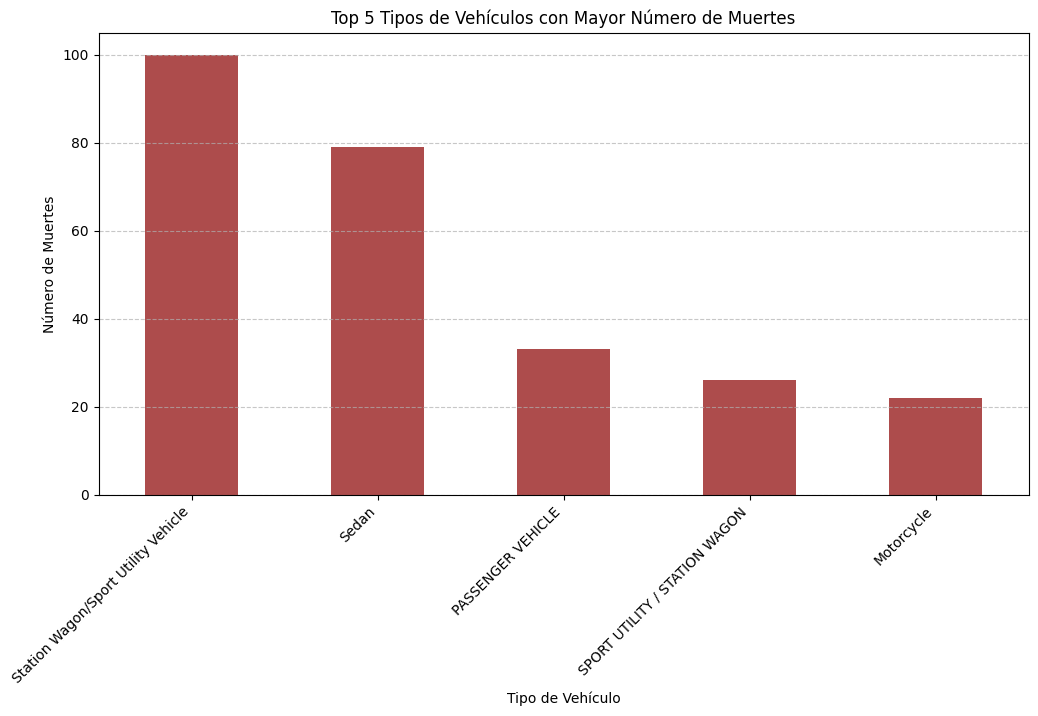

In [103]:

# Crear una columna con el número total de muertes en cada accidente
df['TOTAL_FATALITIES'] = df[['NUMBER OF PEDESTRIANS KILLED',
                             'NUMBER OF CYCLIST KILLED',
                             'NUMBER OF MOTORIST KILLED']].sum(axis=1)

# Seleccionar las columnas de tipos de vehículos involucrados
vehicle_columns = [
    'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2',
    'VEHICLE TYPE CODE 3', 'VEHICLE TYPE CODE 4',
    'VEHICLE TYPE CODE 5'
]

# Convertir el dataframe a formato "largo" para distribuir las muertes entre los vehículos
df_melted = df.melt(id_vars=['TOTAL_FATALITIES'], value_vars=vehicle_columns,
                    var_name="VEHICLE_COLUMN", value_name="VEHICLE_TYPE").dropna()

# Agrupar por tipo de vehículo y sumar las muertes
vehicle_fatalities = df_melted.groupby("VEHICLE_TYPE")['TOTAL_FATALITIES'].sum().sort_values(ascending=False)

# Graficar los 5 tipos de vehículos con más muertes
plt.figure(figsize=(12, 6))
vehicle_fatalities.head(5).plot(kind='bar', color='darkred', alpha=0.7)
plt.xlabel('Tipo de Vehículo')
plt.ylabel('Número de Muertes')
plt.title('Top 5 Tipos de Vehículos con Mayor Número de Muertes')
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Respuesta:

Los SUVs ("Station Wagon/Sport Utility Vehicle") tienen el mayor número de muertes en accidentes.


Los sedanes ("Sedan") también son altamente responsables de muertes, lo cual es esperable debido a su alta presencia en la ciudad.


Otros vehículos involucrados frecuentemente en muertes incluyen vehículos de pasajeros, camionetas y motocicletas.


Las motocicletas tienen una proporción significativa de muertes, lo que sugiere que los accidentes en los que están involucradas pueden ser más letales.